In [82]:
## các thư viện sử dụng
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import time as t

## Các file có trong tệp data
- `application_train.csv / application_test.csv` : Chứa thông tin hồ sơ khách hàng (nhân khẩu học, thu nhập, tình trạng hôn nhân, nghề nghiệp, v.v.).

- `bureau.csv`: Dữ liệu về các khoản vay trước đây của khách hàng tại các tổ chức tín dụng khác (ngoài Home Credit). Bao gồm tình trạng hợp đồng, ngày mở/đóng, số tiền vay, tình trạng quá hạn.

- `bureau_balance.csv` : Bảng chi tiết theo tháng về tình trạng các khoản vay trong bureau.csv (ví dụ: tình trạng hợp đồng từng tháng, có quá hạn hay không).

- `credit_card_balance.csv`: Lịch sử giao dịch thẻ tín dụng của khách hàng: dư nợ, hạn mức, số lần quá hạn, số tháng thanh toán.

- `POS_CASH_balance.csv `: Lịch sử các khoản vay trả góp tại điểm bán (POS) hoặc tiền mặt. Theo dõi trạng thái hợp đồng từng tháng.

- `installments_payments.csv` : Thông tin về các khoản trả góp: số tiền phải trả, số tiền thực trả, ngày trả, có trả đúng hạn hay không.

- `previous_application.csv`: Các khoản vay mà khách hàng đã đăng ký trước đây tại Home Credit (có được chấp nhận hay từ chối, số tiền vay, mục đích vay).

- `HomeCredit_columns_description.csv` : File mô tả chi tiết ý nghĩa của từng cột trong các bảng trên.

- `sample_submission.csv `: File mẫu để nộp kết quả dự đoán (dùng trong Kaggle competition).


In [83]:
# Đường dẫn của data
application_train_path = r'../../IEEE-CIS-Fraud-Detection/Data/Raw_data/home-credit-default-risk/application_train.csv'
application_test_path = r'../../IEEE-CIS-Fraud-Detection/Data/Raw_data/home-credit-default-risk/application_test.csv'
bureau_path = r'../../IEEE-CIS-Fraud-Detection/Data/Raw_data/home-credit-default-risk/bureau.csv'
credit_card_balance_path = r'../../IEEE-CIS-Fraud-Detection/Data/Raw_data/home-credit-default-risk/credit_card_balance.csv'
pos_cash_balance_path = r'../../IEEE-CIS-Fraud-Detection/Data/Raw_data/home-credit-default-risk/POS_CASH_balance.csv'
installment_payments_path = r'../../IEEE-CIS-Fraud-Detection/Data/Raw_data/home-credit-default-risk/installments_payments.csv'
previous_application_path = r'../../IEEE-CIS-Fraud-Detection/Data/Raw_data/home-credit-default-risk/previous_application.csv'
HomeCredit_path = r'../../IEEE-CIS-Fraud-Detection/Data/Raw_data/home-credit-default-risk/HomeCredit_columns_description.csv'


## Đọc Data từ transaction_data_path và identity_data_path

In [84]:
# Đọc data từ transaction_data_path
start_time = t.time()

application_train = pd.read_csv(application_train_path)
bureau = pd.read_csv(bureau_path)
credit_card_balance = pd.read_csv(credit_card_balance_path)
pos_cash_balance = pd.read_csv(pos_cash_balance_path)
installment_payments = pd.read_csv(installment_payments_path)
previous_application = pd.read_csv(previous_application_path)
HomeCredit_path = pd.read_csv(HomeCredit_path,encoding='latin-1') # do file này có chứa các ký tự đặc biệt nên cần thêm encoding='latin-1' để đọc dữ liệu
end_time = t.time()
print(f'Thời gian đọc dữ liệu là: {end_time - start_time} giây')

Thời gian đọc dữ liệu là: 23.10647487640381 giây


## Hàm phân tích tổng quan cho từng tập data

In [85]:
# Hàm tiện ích để hiển thị thông tin cơ bản của dataframe
def display_dataframe_info(df,name):
    print('Kiểm tra cấu trúc của dataframe:', name)
    print('Show ra 5 dòng đầu tiên trong dataframe:', name)
    print('---'*30)
    print(df.head())
    print('---'*30)
    print('Số lượng dòng và cột:', df.shape)
    print('---'*30)
    print('Thông tin chi tiết của dataframe:')
    print(df.info())
    print('---'*30)
    print('Các cột có trong datafarme:', df.columns)
    print('---'*30)
    print('Thống kê tổng quát data:')
    print(df.describe())


#----------------------------------------------------------
# kiểm tra giá trị bị thiếu
def check_missing_values(df, name, sort_by="count", ascending=False):
    print('Kiểm tra giá trị bị thiếu trong dataframe:', name)
    
    # Tạo dataframe chứa thông tin missing
    missing_info = []
    for col in df.columns:
        missing_val = df[col].isnull().sum()
        percent = (missing_val / len(df[col])) * 100
        missing_info.append([col, missing_val, percent])
    
    # Chuyển sang DataFrame để dễ sort
    missing_df = pd.DataFrame(missing_info, columns=["Column", "MissingCount", "MissingPercent"])
    
    # Sắp xếp theo yêu cầu
    if sort_by == "count":
        missing_df = missing_df.sort_values(by="MissingCount", ascending=ascending)
    elif sort_by == "percent":
        missing_df = missing_df.sort_values(by="MissingPercent", ascending=ascending)
    
    # In kết quả
    for _, row in missing_df.iterrows():
        print(f"Cột {row['Column']} có \033[4m{row['MissingCount']}\033[0m missing values "
              f"và chiếm \033[4m{row['MissingPercent']:.2f}%\033[0m")
        
#----------------------------------------------------------
# kiểm tra giá trị bị trùng lập
def check_duplicateted(df, name):
    print('Kiểm tra giá trị bị trùng lặp trong dataframe:', name)
    print(df.duplicated().sum())
#----------------------------------------------------------
def check_unique_values(df, name):
    print('Kiểm tra giá trị duy nhất trong dataframe:', name)
    for col in df.columns:
        unique_count = df[col].nunique()
        print(f"Cột {col} có \033[4m{unique_count}\033[0m giá trị duy nhất.")
#----------------------------------------------------------
# kiểm tra mối tương quan giữa các cột
def check_corr(df, name):
    print('Kiểm tra mối tương quan giữa các cột trong dataframe:', name)
    df_numeric = df.select_dtypes(include='number')
    corr_matrix = df_numeric.corr()
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f")
    plt.title('Correlation Matrix')
    plt.show()
#----------------------------------------------------------
# kiểm tra sự cân bằng của biến mục tiêu
def check_target_balance(df, target_col):
    print(f'Kiểm tra sự cân bằng của biến mục tiêu: {target_col}')
    counts = df[target_col].value_counts(normalize=True)
    print(counts)
#----------------------------------------------------------
# kiểm tra phân phối của các biến số
def check_skewness(df, name):
    numeric_cols = df.select_dtypes(include='number').columns
    skew_df = df[numeric_cols].skew().sort_values(ascending=False)
    print(f'Độ lệch của các cột số (càng cao càng lệch):')
    print(skew_df)

Kiểm tra mối tương quan giữa các cột trong dataframe: application_train


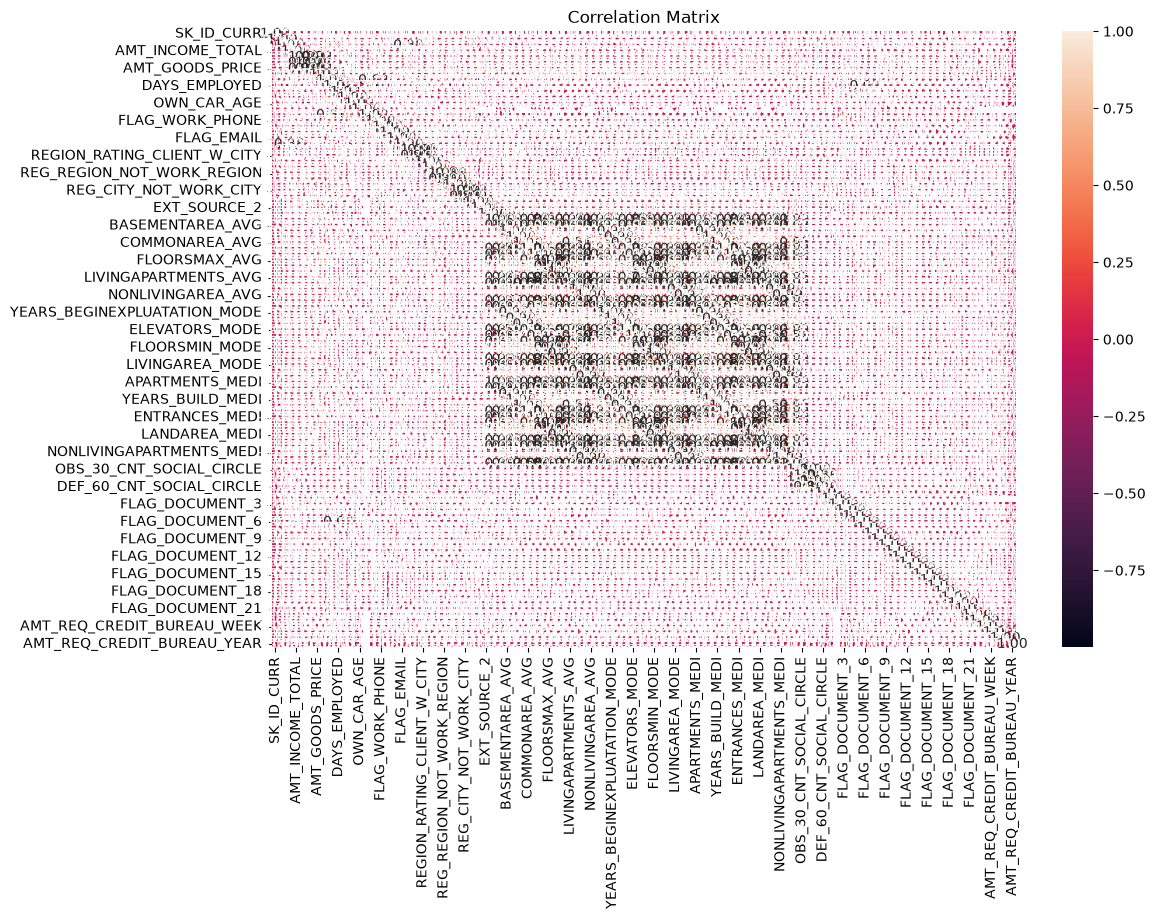

In [86]:
check_corr(application_train, 'application_train')

In [87]:
display_dataframe_info(application_train, 'application_train')


Kiểm tra cấu trúc của dataframe: application_train
Show ra 5 dòng đầu tiên trong dataframe: application_train
------------------------------------------------------------------------------------------
   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0      100002       1         Cash loans           M            N   
1      100003       0         Cash loans           F            N   
2      100004       0    Revolving loans           M            Y   
3      100006       0         Cash loans           F            N   
4      100007       0         Cash loans           M            N   

  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0               Y             0          202500.0    406597.5      24700.5   
1               N             0          270000.0   1293502.5      35698.5   
2               Y             0           67500.0    135000.0       6750.0   
3               Y             0          135000.0    312682.5      29686

# Cấu trúc dữ liệu dự án Home Credit

Dưới đây là phân loại các nhóm đặc trưng (features) trong tập dữ liệu `application_train.csv`.

## 1. Nhóm Định danh & Mục tiêu (Target)
- `SK_ID_CURR`: ID khách hàng (khóa chính để liên kết dữ liệu).
- `TARGET`: **Biến mục tiêu**. 
    - `1`: Khách hàng gặp khó khăn thanh toán (Nợ xấu).
    - `0`: Khách hàng trả nợ đúng hạn.

## 2. Nhóm Thông tin cá nhân (Nhân khẩu học)
Mô tả chi tiết về hồ sơ khách hàng:
- **Cơ bản**: `CODE_GENDER` (Giới tính), `CNT_CHILDREN` (Số lượng con), `NAME_FAMILY_STATUS` (Tình trạng hôn nhân).
- **Thời gian**: `DAYS_BIRTH` (Tuổi), `DAYS_ID_PUBLISH` (Thời điểm cấp CCCD).
- **Giáo dục & Công việc**: `NAME_EDUCATION_TYPE` (Học vấn), `NAME_INCOME_TYPE` (Nguồn thu nhập), `OCCUPATION_TYPE` (Nghề nghiệp), `ORGANIZATION_TYPE` (Loại hình tổ chức).

## 3. Nhóm Tình trạng tài chính (Khả năng chi trả)
Xác định năng lực tài chính của khách hàng:
- **Thu nhập & Khoản vay**: `AMT_INCOME_TOTAL` (Tổng thu nhập), `AMT_CREDIT` (Tổng số tiền vay), `AMT_ANNUITY` (Số tiền trả góp hàng tháng).
- **Tài sản**: `NAME_HOUSING_TYPE` (Loại nhà ở), `FLAG_OWN_REALTY` (Sở hữu bất động sản).

## 4. Nhóm Dữ liệu từ bên thứ ba (EXT_SOURCE)
- `EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3`: Các điểm số tín dụng tổng hợp từ các nguồn dữ liệu bên ngoài. 
    - > **Lưu ý**: Đây là nhóm biến có khả năng dự báo mạnh nhất cho mô hình.

## 5. Nhóm Kỹ thuật & Lịch sử tín dụng
- **Thông tin liên lạc**: `REGION_RATING_CLIENT` (Đánh giá khu vực cư trú), `FLAG_PHONE`, `FLAG_EMAIL`.
- **Lịch sử yêu cầu**: `AMT_REQ_CREDIT_BUREAU_...` (Số lần hỏi vay trong các khung thời gian từ giờ đến năm).
    - > *Insight*: Tần suất hỏi vay cao liên tục trong thời gian ngắn thường là dấu hiệu của rủi ro tài chính.

## 6. Nhóm thông tin bổ sung (Dữ liệu "thô")
- **Thông tin bất động sản**: `APARTMENTS_AVG`, `LIVINGAREA_AVG`, `FLOORSMAX_AVG`... (Mô tả chi tiết căn nhà khách hàng đang ở).
- **Giấy tờ xác thực**: `FLAG_DOCUMENT_2` đến `FLAG_DOCUMENT_21` (Các loại tài liệu khách hàng đã cung cấp cho tổ chức tín dụng).

In [88]:
check_missing_values(application_train, 'application_train', sort_by="count", ascending=False)

Kiểm tra giá trị bị thiếu trong dataframe: application_train
Cột COMMONAREA_AVG có 214865 missing values và chiếm 69.87%
Cột COMMONAREA_MODE có 214865 missing values và chiếm 69.87%
Cột COMMONAREA_MEDI có 214865 missing values và chiếm 69.87%
Cột NONLIVINGAPARTMENTS_MEDI có 213514 missing values và chiếm 69.43%
Cột NONLIVINGAPARTMENTS_MODE có 213514 missing values và chiếm 69.43%
Cột NONLIVINGAPARTMENTS_AVG có 213514 missing values và chiếm 69.43%
Cột FONDKAPREMONT_MODE có 210295 missing values và chiếm 68.39%
Cột LIVINGAPARTMENTS_AVG có 210199 missing values và chiếm 68.35%
Cột LIVINGAPARTMENTS_MEDI có 210199 missing values và chiếm 68.35%
Cột LIVINGAPARTMENTS_MODE có 210199 missing values và chiếm 68.35%
Cột FLOORSMIN_MODE có 208642 missing values và chiếm 67.85%
Cột FLOORSMIN_AVG có 208642 missing values và chiếm 67.85%
Cột FLOORSMIN_MEDI có 208642 missing values và chiếm 67.85%
Cột YEARS_BUILD_AVG có 204488 missing values và chiếm 66.50%
Cột YEARS_BUILD_MODE có 204488 missing value

C:\Users\LỘC2007\AppData\Local\Temp\ipykernel_37928\2329751803.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_df.index, y=missing_df.values, palette="viridis")


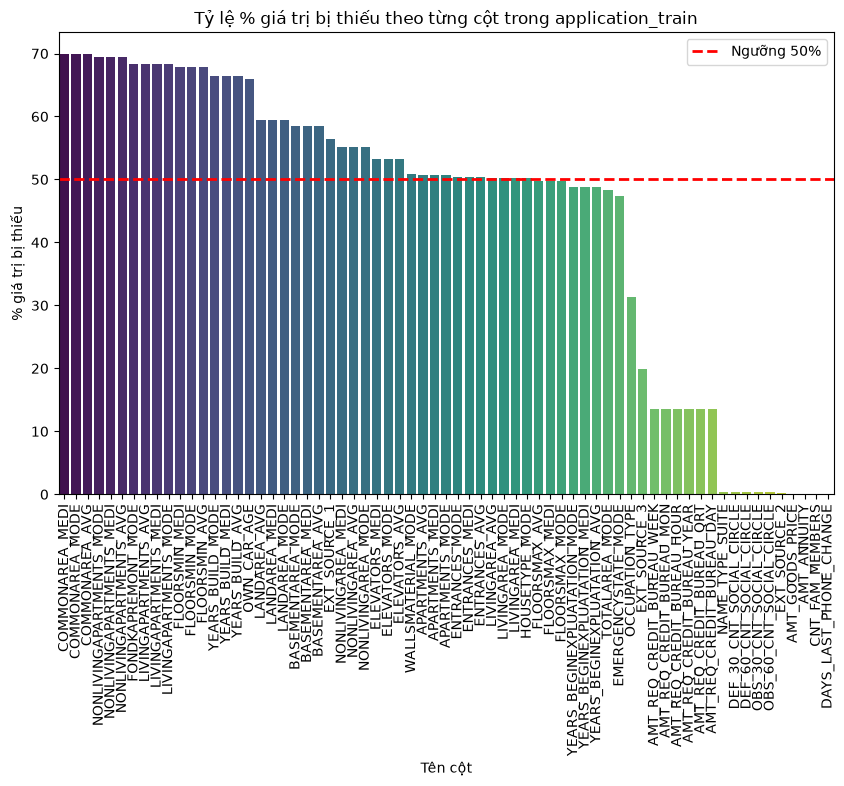

C:\Users\LỘC2007\AppData\Local\Temp\ipykernel_37928\2329751803.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=high_missing_df.index, y=high_missing_df.values, palette="magma")


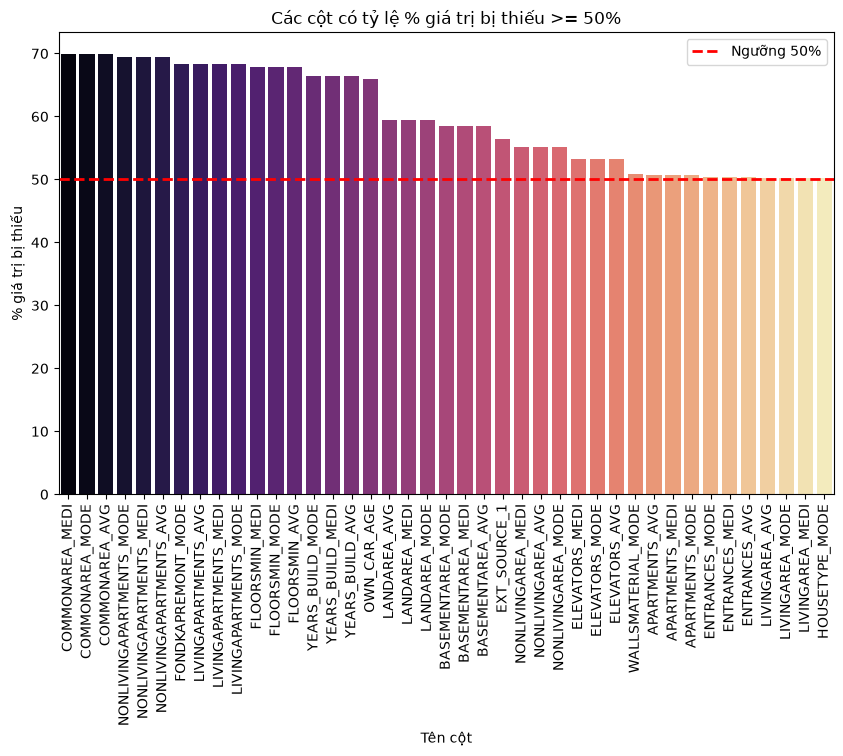

Các cột có tỷ lệ % giá trị bị thiếu >= 50%:
- COMMONAREA_MEDI: 69.87%
- COMMONAREA_MODE: 69.87%
- COMMONAREA_AVG: 69.87%
- NONLIVINGAPARTMENTS_MODE: 69.43%
- NONLIVINGAPARTMENTS_MEDI: 69.43%
- NONLIVINGAPARTMENTS_AVG: 69.43%
- FONDKAPREMONT_MODE: 68.39%
- LIVINGAPARTMENTS_AVG: 68.35%
- LIVINGAPARTMENTS_MEDI: 68.35%
- LIVINGAPARTMENTS_MODE: 68.35%
- FLOORSMIN_MEDI: 67.85%
- FLOORSMIN_MODE: 67.85%
- FLOORSMIN_AVG: 67.85%
- YEARS_BUILD_MODE: 66.50%
- YEARS_BUILD_MEDI: 66.50%
- YEARS_BUILD_AVG: 66.50%
- OWN_CAR_AGE: 65.99%
- LANDAREA_AVG: 59.38%
- LANDAREA_MEDI: 59.38%
- LANDAREA_MODE: 59.38%
- BASEMENTAREA_MODE: 58.52%
- BASEMENTAREA_MEDI: 58.52%
- BASEMENTAREA_AVG: 58.52%
- EXT_SOURCE_1: 56.38%
- NONLIVINGAREA_MEDI: 55.18%
- NONLIVINGAREA_AVG: 55.18%
- NONLIVINGAREA_MODE: 55.18%
- ELEVATORS_MEDI: 53.30%
- ELEVATORS_MODE: 53.30%
- ELEVATORS_AVG: 53.30%
- WALLSMATERIAL_MODE: 50.84%
- APARTMENTS_AVG: 50.75%
- APARTMENTS_MEDI: 50.75%
- APARTMENTS_MODE: 50.75%
- ENTRANCES_MODE: 50.35%
- ENTRA

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tính số lượng và phần trăm giá trị thiếu theo từng cột
missing_values = application_train.isnull().sum()
missing_percent = 100 * missing_values / len(application_train)

# Lọc ra cột có dữ liệu thiếu
missing_df = missing_percent[missing_percent > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=missing_df.index, y=missing_df.values, palette="viridis")
plt.xticks(rotation=90)
plt.ylabel('% giá trị bị thiếu')
plt.xlabel('Tên cột')
plt.title('Tỷ lệ % giá trị bị thiếu theo từng cột trong application_train')
plt.xlim(-0.5, len(missing_df)-0.5)
plt.axhline(y=50, color='red', linestyle='--', linewidth=2, label='Ngưỡng 50%')
plt.legend()
plt.show()

# Biểu đồ riêng cho các cột có tỷ lệ thiếu >= 50%
high_missing_df = missing_df[missing_df >= 50]

plt.figure(figsize=(10, 6))
sns.barplot(x=high_missing_df.index, y=high_missing_df.values, palette="magma")
plt.xticks(rotation=90)
plt.ylabel('% giá trị bị thiếu')
plt.xlabel('Tên cột')
plt.title('Các cột có tỷ lệ % giá trị bị thiếu >= 50%')
plt.xlim(-0.5, len(high_missing_df)-0.5)
plt.axhline(y=50, color='red', linestyle='--', linewidth=2, label='Ngưỡng 50%')
plt.legend()
plt.show()


print("Các cột có tỷ lệ % giá trị bị thiếu >= 50%:")
for col in high_missing_df.index:
    print(f"- {col}: {high_missing_df[col]:.2f}%")

### Chú thích 
1. Mục tiêu biểu đồ
    - Biểu đồ được tạo ra nhằm kiểm tra tỷ lệ dữ liệu bị thiếu theo từng cột.
    - Từ đó, ta có thể đánh giá chất lượng tập dữ liệu và đưa ra quyết định xử lý phù hợp (loại bỏ, thay thế, hoặc giữ lại).

2. Vấn đề phát hiện
    - Kết quả cho thấy có nhiều cột có tỷ lệ dữ liệu thiếu trên 50%.
    - Đây là một dấu hiệu nghiêm trọng, vì dữ liệu thiếu quá nhiều sẽ làm giảm độ tin cậy của mô hình dự đoán.
    - Nếu giữ nguyên, mô hình có thể bị thiên lệch, giảm độ chính xác, hoặc thậm chí không học được thông tin hữu ích.

3. Giải thích ý nghĩa
    - Các cột vượt ngưỡng 50% thường được coi là không đủ thông tin để sử dụng.
    - Việc xử lý có thể theo hướng:
        - Loại bỏ cột: nếu dữ liệu thiếu quá nhiều và không thể bổ sung.
        - Thay thế giá trị: nếu cột quan trọng, có thể dùng giá trị trung bình, median, hoặc mô hình dự đoán để điền.

    - Đường ngang màu đỏ ở mức 50% trong biểu đồ chính là ngưỡng cảnh báo để dễ dàng nhận diện.

In [90]:
check_duplicateted(application_train, 'application_train')

Kiểm tra giá trị bị trùng lặp trong dataframe: application_train
0


C:\Users\LỘC2007\AppData\Local\Temp\ipykernel_37928\4226181608.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Column', y='UniqueCount', data=unique_df, palette="viridis")


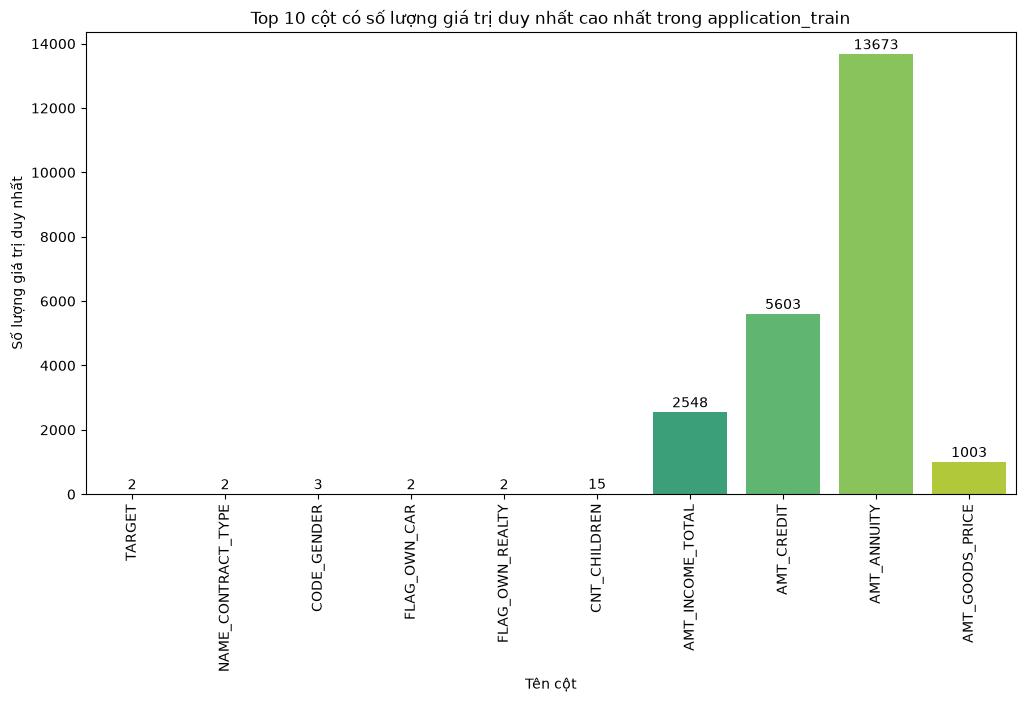

In [91]:
# biểu đồ thể hiện giá trị duy nhất của từng cột trong dataframe
unique_df = pd.DataFrame({'Column': application_train.columns, 
                          'UniqueCount': [len(application_train[col].unique()) 
                                          for col in application_train.columns]})
unique_df = unique_df.iloc[1:11]  # Lấy 10 cột có số lượng giá trị duy nhất cao nhất

plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Column', y='UniqueCount', data=unique_df, palette="viridis")

plt.xticks(rotation=90)
plt.ylabel('Số lượng giá trị duy nhất')
plt.xlabel('Tên cột')
plt.title('Top 10 cột có số lượng giá trị duy nhất cao nhất trong application_train')

# Hiển thị giá trị trên mỗi cột
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2,   # vị trí ngang (giữa cột)
            p.get_height() + 50,           # vị trí dọc (cao hơn cột một chút)
            int(p.get_height()),           # giá trị hiển thị
            ha='center', va='bottom', fontsize=10, color='black')

plt.show()

In [92]:
check_unique_values(application_train, 'application_train')

Kiểm tra giá trị duy nhất trong dataframe: application_train
Cột SK_ID_CURR có 307511 giá trị duy nhất.
Cột TARGET có 2 giá trị duy nhất.
Cột NAME_CONTRACT_TYPE có 2 giá trị duy nhất.
Cột CODE_GENDER có 3 giá trị duy nhất.
Cột FLAG_OWN_CAR có 2 giá trị duy nhất.
Cột FLAG_OWN_REALTY có 2 giá trị duy nhất.
Cột CNT_CHILDREN có 15 giá trị duy nhất.
Cột AMT_INCOME_TOTAL có 2548 giá trị duy nhất.
Cột AMT_CREDIT có 5603 giá trị duy nhất.
Cột AMT_ANNUITY có 13672 giá trị duy nhất.
Cột AMT_GOODS_PRICE có 1002 giá trị duy nhất.
Cột NAME_TYPE_SUITE có 7 giá trị duy nhất.
Cột NAME_INCOME_TYPE có 8 giá trị duy nhất.
Cột NAME_EDUCATION_TYPE có 5 giá trị duy nhất.
Cột NAME_FAMILY_STATUS có 6 giá trị duy nhất.
Cột NAME_HOUSING_TYPE có 6 giá trị duy nhất.
Cột REGION_POPULATION_RELATIVE có 81 giá trị duy nhất.
Cột DAYS_BIRTH có 17460 giá trị duy nhất.
Cột DAYS_EMPLOYED có 12574 giá trị duy nhất.
Cột DAYS_REGISTRATION có 15688 giá trị duy nhất.
Cột DAYS_ID_PUBLISH có 6168 giá trị duy nhất.
Cột OWN_CAR_AG

In [93]:
check_target_balance(application_train, 'TARGET')

Kiểm tra sự cân bằng của biến mục tiêu: TARGET
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


In [94]:
check_skewness(application_train, 'application_train')

Độ lệch của các cột số (càng cao càng lệch):
FLAG_DOCUMENT_12                392.114779
AMT_INCOME_TOTAL                391.559654
FLAG_DOCUMENT_10                209.589054
FLAG_DOCUMENT_2                 153.791817
AMT_REQ_CREDIT_BUREAU_QRT       134.365776
                                   ...    
YEARS_BEGINEXPLUATATION_MODE    -14.755318
YEARS_BEGINEXPLUATATION_AVG     -15.515264
YEARS_BEGINEXPLUATATION_MEDI    -15.573124
FLAG_CONT_MOBILE                -23.081172
FLAG_MOBIL                     -554.536744
Length: 106, dtype: float64


# Tìm hiểu sâu hơn vào tập data

## Phần thông tin khách hàng
- CODE_GENDER: Giới tính.
- CNT_CHILDREN: Số lượng con cái.
    - DAYS_BIRTH: Tuổi của khách hàng (đơn vị: ngày, tính ngược từ thời điểm hiện tại).
    - NAME_FAMILY_STATUS: Tình trạng hôn nhân.
    - NAME_EDUCATION_TYPE: Trình độ học vấn.

### 1 Cột giới tính
- Kiểm tra tổng quan cột df.describe()
- Kiểm tra dũ liệu bị thiếu
- Phân tích tỉ lệ giới tính 
- Tỷ lệ giới tính gian lận

In [95]:
application_train['CODE_GENDER'].describe()

count     307511
unique         3
top            F
freq      202448
Name: CODE_GENDER, dtype: object

In [96]:
application_train['CODE_GENDER'].unique()

<StringArray>
['M', 'F', 'XNA']
Length: 3, dtype: str

In [97]:
application_train['CODE_GENDER'].isnull().sum()

np.int64(0)

Biểu đồ phân phối giá trị giới tính trong data
Số lượng các giá trị của mỗi thành phần trong cột CODE_GENDER:
CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64


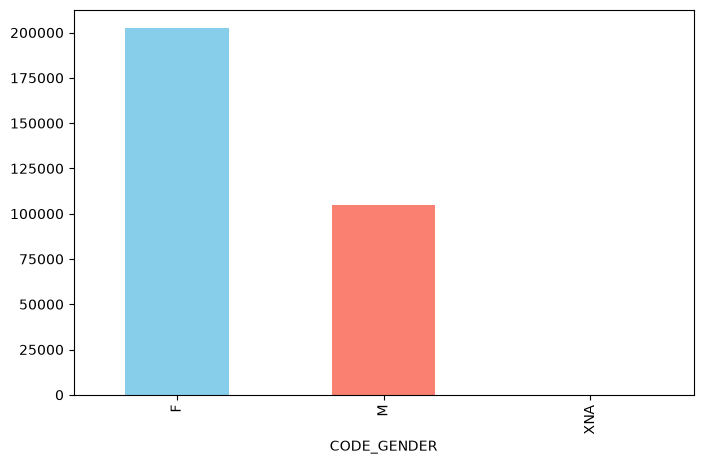

In [98]:
application_train['CODE_GENDER'].value_counts().plot(kind='bar', figsize=(8, 5), color=['skyblue', 'salmon'])
print("Biểu đồ phân phối giá trị giới tính trong data")
print("Số lượng các giá trị của mỗi thành phần trong cột CODE_GENDER:")
print(application_train['CODE_GENDER'].value_counts())

C:\Users\LỘC2007\AppData\Local\Temp\ipykernel_37928\489091124.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='CODE_GENDER', data=df_fraud, palette="viridis")


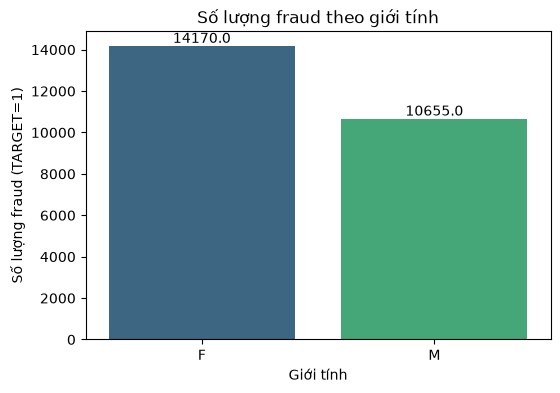

In [99]:
df = application_train[['CODE_GENDER', 'TARGET']]
df_female_fraud= df[(df['CODE_GENDER'] == 'F') & (df['TARGET'] == 1)]
df_male_fraud= df[(df['CODE_GENDER'] == 'M') & (df['TARGET'] == 1)]
df_fraud = pd.concat([df_female_fraud, df_male_fraud], axis=0)

# Vẽ biểu đồ số lượng fraud theo giới tính
plt.figure(figsize=(6, 4))
sns.countplot(x='CODE_GENDER', data=df_fraud, palette="viridis")

plt.xlabel('Giới tính')
plt.ylabel('Số lượng fraud (TARGET=1)')
plt.title('Số lượng fraud theo giới tính')

for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), 
                       textcoords='offset points')
plt.show()

 - Biểu đồ 1 và 2 được tạo nên với mục đích kiểm tra xem giới tính nào sở hữu thẻ tính dụng nhiều nhất và có số lượng không có khả năng chi trả lớn nhất
 - Biểu đồ cho thấy nữ giới sở hữu nữ giới và không có khả năng chi trả khoảng vay
    - Lý do mà nữ giới có tỉ lệ không thể chi trả cao hơn là nam có thể là do hành mua sắm, trang điểm, ăn uống (đa số sẽ là đồ dắt tiền)
    

### Phân tích cột CNT_CHILDREN: Số lượng con cái. 

In [100]:
df = application_train['CNT_CHILDREN']

In [101]:
df.describe()

count    307511.000000
mean          0.417052
std           0.722121
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          19.000000
Name: CNT_CHILDREN, dtype: float64

In [102]:
df.isnull().sum()

np.int64(0)

In [103]:
df.unique()

array([ 0,  1,  2,  3,  4,  7,  5,  6,  8,  9, 11, 12, 10, 19, 14])

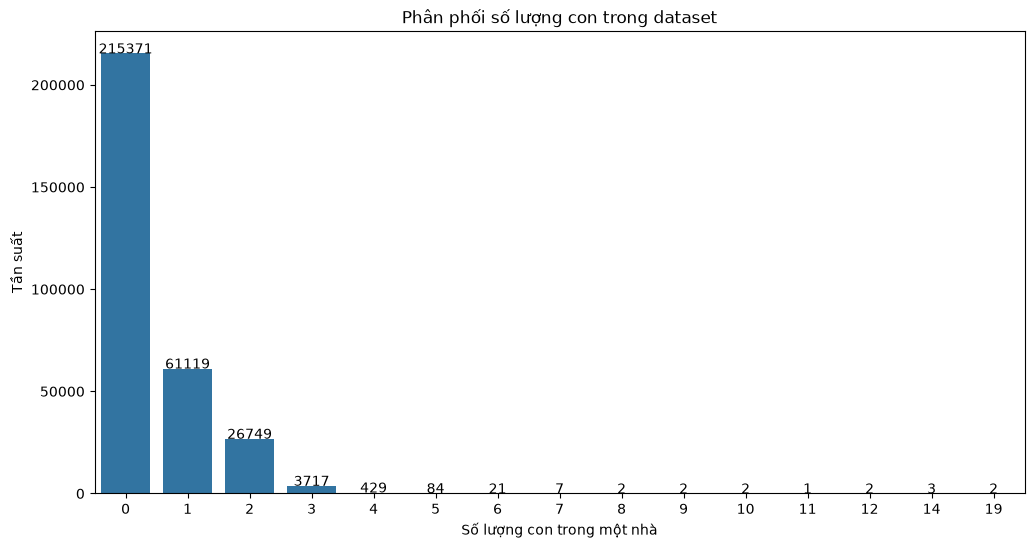

In [104]:
# Đếm số lượng từng giá trị unique
counts = df.value_counts().sort_index()

plt.figure(figsize=(12,6))
ax = sns.barplot(x=counts.index, y=counts.values)

plt.xlabel('Số lượng con trong một nhà')
plt.ylabel('Tần suất')
plt.title('Phân phối số lượng con trong dataset')

# Hiển thị số lượng trên đầu mỗi cột
for i, v in enumerate(counts.values):
    ax.text(i, v + 50, str(v), ha='center', fontsize=10)

plt.show()

## So sánh cột CNT_CHILDREN và TARGET 

In [ ]:
df = application_train[['CNT_CHILDREN','TARGET']]

In [106]:
# Nhóm theo CNT_CHILDREN và đếm số lượng TARGET=1
counts = df[df['TARGET'] == 1]['CNT_CHILDREN'].value_counts().sort_index()

plt.figure(figsize=(10,5))
ax = sns.barplot(x=counts.index, y=counts.values)

plt.xlabel('Số lượng con trong một nhà')
plt.ylabel('Số lượng khách hàng bị default (TARGET=1)')
plt.title('Phân phối số lượng default theo số con')

# Hiển thị số lượng ngay trên đầu mỗi cột
for i, v in enumerate(counts.values):
    ax.text(i, v + 50, str(v), ha='center', fontsize=10)

plt.show()


KeyError: 'TARGET'

### Phần trăm những người ở từ 1-4 con, bị đánh taget là 1 

In [ ]:
df = application_train[['CNT_CHILDREN','TARGET']]

In [ ]:
for uni_value in df['CNT_CHILDREN'].unique():   
    df_unique_val = df[df['CNT_CHILDREN'] == uni_value]
    df_taget_1 = df[(df['CNT_CHILDREN'] == uni_value) & df['TARGET'] == 1]
    percent_df_val = (len(df_taget_1)/ len(df_unique_val))* 100
    print(f'Tỉ lệ không trả được nợ dựa trên số lượng con là {uni_value} :{percent_df_val:.2f}%')

Tỉ lệ không trả được nợ dựa trên số lượng con là 0 :7.71%
Tỉ lệ không trả được nợ dựa trên số lượng con là 1 :8.92%
Tỉ lệ không trả được nợ dựa trên số lượng con là 2 :8.72%
Tỉ lệ không trả được nợ dựa trên số lượng con là 3 :9.63%
Tỉ lệ không trả được nợ dựa trên số lượng con là 4 :12.82%
Tỉ lệ không trả được nợ dựa trên số lượng con là 7 :0.00%
Tỉ lệ không trả được nợ dựa trên số lượng con là 5 :8.33%
Tỉ lệ không trả được nợ dựa trên số lượng con là 6 :28.57%
Tỉ lệ không trả được nợ dựa trên số lượng con là 8 :0.00%
Tỉ lệ không trả được nợ dựa trên số lượng con là 9 :100.00%
Tỉ lệ không trả được nợ dựa trên số lượng con là 11 :100.00%
Tỉ lệ không trả được nợ dựa trên số lượng con là 12 :0.00%
Tỉ lệ không trả được nợ dựa trên số lượng con là 10 :0.00%
Tỉ lệ không trả được nợ dựa trên số lượng con là 19 :0.00%
Tỉ lệ không trả được nợ dựa trên số lượng con là 14 :0.00%


# Báo cáo phân tích đặc trưng: Số lượng con (`CNT_CHILDREN`)

## 1. Phân tích phân phối và giá trị ngoại lệ (Outliers)
Qua khảo sát biểu đồ phân phối của biến `CNT_CHILDREN`, chúng ta ghi nhận sự xuất hiện của các giá trị ngoại lệ (outliers) đối với những hộ gia đình có trên 5 người con.

- **Đánh giá thực tế:** Mặc dù đây là các trường hợp có khả năng xảy ra trong thực tế, nhưng tần suất xuất hiện rất thấp.
- **Ảnh hưởng đến mô hình:** Các giá trị cực đoan này có thể gây nhiễu, làm giảm độ chính xác và khả năng tổng quát hóa của mô hình dự đoán. Việc xử lý nhóm này là cần thiết để tập trung vào hành vi của đại đa số khách hàng.

## 2. Mối tương quan giữa số lượng con và khả năng vỡ nợ (`TARGET`)
Kết quả phân tích phân khúc (segmentation) cho thấy mối tương quan rõ rệt giữa quy mô gia đình và rủi ro tín dụng:

- **Xu hướng vay:** Nhóm khách hàng có **0 con** chiếm tỷ trọng lớn nhất, theo sau là nhóm có 1 và 2 con. Điều này phản ánh nhu cầu vay vốn cao ở nhóm khách hàng trẻ hoặc người có ít trách nhiệm nuôi dạy con cái hơn.
- **Rủi ro vỡ nợ:** Dữ liệu cho thấy sự chênh lệch rõ rệt về tỷ lệ vỡ nợ (`TARGET=1`):
    - Nhóm khách hàng có **0 con** có tỷ lệ vỡ nợ thấp nhất, đạt mức **7.71%**.
    - Tỷ lệ vỡ nợ có xu hướng **tăng dần** tương ứng với sự gia tăng số lượng con trong gia đình.
    - Tỷ lệ này đạt mức cao nhất ở nhóm khách hàng có từ 5 người con trở lên.

## 3. Kết luận và đề xuất xử lý
Từ các phân tích trên, có thể khẳng định: **Số lượng con cái tỷ lệ thuận với xác suất vỡ nợ của khách hàng.** ### Đề xuất hành động:
1. **Xử lý dữ liệu:** Áp dụng phương pháp gộp nhóm (binning) hoặc *Winsorization* cho các trường hợp có từ 5 người con trở lên để hạn chế nhiễu từ các giá trị ngoại lệ thay vì xóa bỏ hoàn toàn.
2. **Feature Engineering:** Tiếp tục sử dụng biến `CNT_CHILDREN` vì đây là biến số có khả năng dự báo rủi ro tốt.
3. **Phân tích bổ trợ:** Nên kết hợp thêm biến `NAME_FAMILY_STATUS` để hiểu rõ hơn về tình trạng hôn nhân và hoàn cảnh kinh tế, tránh kết luận vội vàng về trạng thái gia đình của khách hàng.

### Phân tích cột NAME_FAMILY_STATUS

In [ ]:
df = application_train['NAME_FAMILY_STATUS']

In [ ]:
df.describe()

count      307511
unique          6
top       Married
freq       196432
Name: NAME_FAMILY_STATUS, dtype: object

In [ ]:
df.unique()

<StringArray>
['Single / not married',              'Married',       'Civil marriage',
                'Widow',            'Separated',              'Unknown']
Length: 6, dtype: str

### Ý nghĩa các giá trị trong cột:
- Single / not married: Người độc thân, chưa từng kết hôn.
- Married: Người đã kết hôn hợp pháp.
- Civil marriage: Kết hôn thực tế (sống chung như vợ chồng nhưng không đăng ký kết hôn chính thức).
- Widow: Người góa phụ 
- Separated: Người đã ly thân hoặc đã ly hôn.
- Unknown: Dữ liệu bị thiếu hoặc không được xác định.


In [ ]:
df.isnull().sum()

np.int64(0)

C:\Users\LỘC2007\AppData\Local\Temp\ipykernel_37928\455069695.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette="viridis")


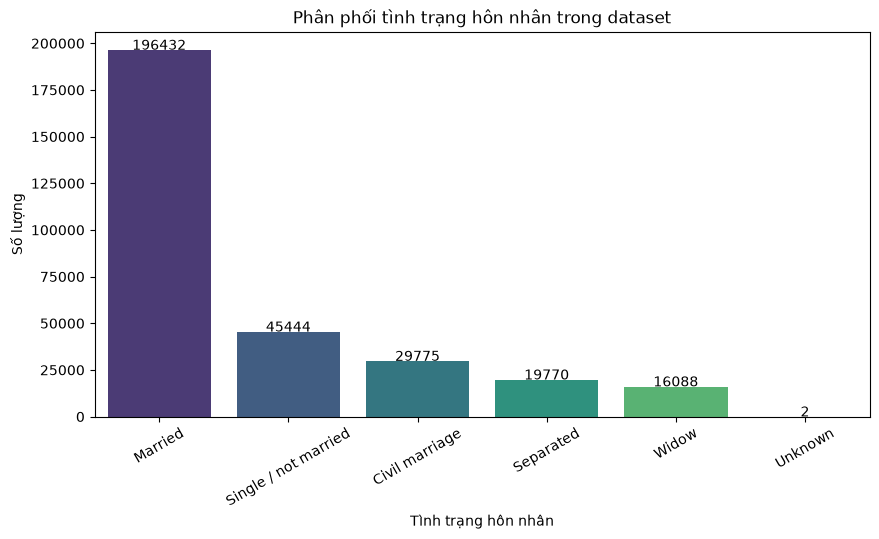

In [ ]:
# Đếm số lượng từng giá trị unique
counts = df.value_counts()

plt.figure(figsize=(10,5))
ax = sns.barplot(x=counts.index, y=counts.values, palette="viridis")

plt.xlabel('Tình trạng hôn nhân')
plt.ylabel('Số lượng')
plt.title('Phân phối tình trạng hôn nhân trong dataset')

# Hiển thị số lượng trên đầu mỗi cột
for i, v in enumerate(counts.values):
    ax.text(i, v + 100, str(v), ha='center', fontsize=10)

plt.xticks(rotation=30)  # xoay nhãn X cho dễ đọc
plt.show()

In [ ]:
df = application_train[['NAME_FAMILY_STATUS','TARGET']]

C:\Users\LỘC2007\AppData\Local\Temp\ipykernel_37928\331892272.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette="viridis")


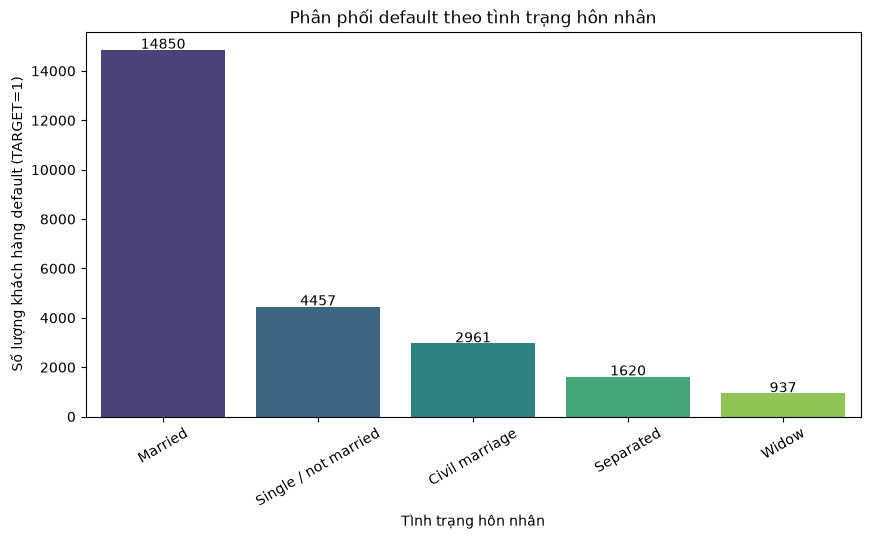

In [ ]:
df_default = df[df['TARGET'] == 1]
counts = df_default['NAME_FAMILY_STATUS'].value_counts()

plt.figure(figsize=(10,5))
ax = sns.barplot(x=counts.index, y=counts.values, palette="viridis")

plt.xlabel('Tình trạng hôn nhân')
plt.ylabel('Số lượng khách hàng default (TARGET=1)')
plt.title('Phân phối default theo tình trạng hôn nhân')

# Hiển thị số lượng trên đầu mỗi cột
for i, v in enumerate(counts.values):
    ax.text(i, v + 50, str(v), ha='center', fontsize=10)

plt.xticks(rotation=30)  # xoay nhãn X cho dễ đọc
plt.show()

In [ ]:
for uni_value in df['NAME_FAMILY_STATUS'].unique():   
    df_unique_val = df[df['NAME_FAMILY_STATUS'] == uni_value]
    df_taget_1 = df[(df['NAME_FAMILY_STATUS'] == uni_value) & df['TARGET'] == 1]
    percent_df_val = (len(df_taget_1)/ len(df_unique_val))* 100
    print(f'Tỉ lệ không trả được nợ dựa trên số lượng con là {uni_value} :{percent_df_val:.2f}%')

Tỉ lệ không trả được nợ dựa trên số lượng con là Single / not married :9.81%
Tỉ lệ không trả được nợ dựa trên số lượng con là Married :7.56%
Tỉ lệ không trả được nợ dựa trên số lượng con là Civil marriage :9.94%
Tỉ lệ không trả được nợ dựa trên số lượng con là Widow :5.82%
Tỉ lệ không trả được nợ dựa trên số lượng con là Separated :8.19%
Tỉ lệ không trả được nợ dựa trên số lượng con là Unknown :0.00%


- Biểu đồ một thể hiện số lượng các tình trạng hôn nhân có trogn dữ liệu
    - Tình trạng hôn nhân chiếm tỉ trong cao nhất, có tính ảnh hưởng tới model cáo nhất nên cần xử lí tốt nhất
- Biểu đồ hai thể hiện số lượng các tình trạng hôn nhân bị target là 1 trong dữ liệu

### Phân tích cột DAYS_BIRTH

In [ ]:
df = application_train[['DAYS_BIRTH','TARGET']]

In [ ]:
df.head()

,DAYS_BIRTH,TARGET
0,-9461,1
1,-16765,0
2,-19046,0
3,-19005,0
4,-19932,0


In [ ]:
df['DAYS_BIRTH'].describe()

count    307511.000000
mean     -16036.995067
std        4363.988632
min      -25229.000000
25%      -19682.000000
50%      -15750.000000
75%      -12413.000000
max       -7489.000000
Name: DAYS_BIRTH, dtype: float64

In [ ]:
df['DAYS_BIRTH'].isnull().sum()

np.int64(0)

In [ ]:
df['DAYS_BIRTH'].unique()

array([ -9461, -16765, -19046, ...,  -7951,  -7857, -25061],
      shape=(17460,))

In [ ]:
df['DAYS_BIRTH'] = abs(round(df['DAYS_BIRTH']/365))

In [ ]:
df = application_train['NAME_CONTRACT_TYPE']

In [ ]:
df = application_train[['CNT_CHILDREN','TARGET']]

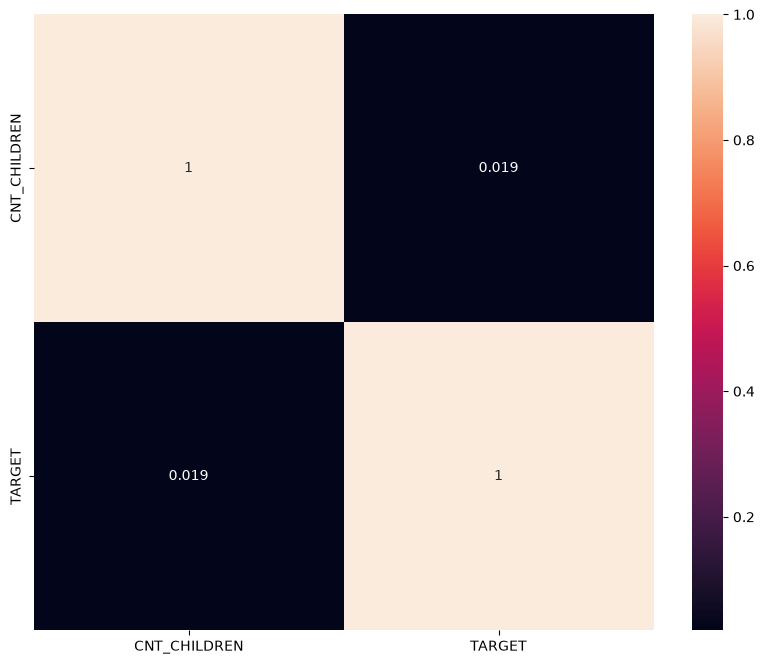

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True)
plt.show()